In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import torch
import src.metropolis_hastings as mh
import time

from src.time_varying_vine_copula import tv_vinecop, obs_transform_pendulum, action_transform_pendulum
from rl_code.modelnp import pendulum
from rl_code.lspi import LSPI


In [2]:
env = gym.make("InvertedPendulum-v5")  
# Reset environment to start a new episode
observation, info = env.reset(seed=123) 
# observation: what the agent can "see" - cart position, velocity
# info: extra debugging information (usually not needed for basic learning)

print(f"Starting observation: {observation}")

n = 200 #truncation limit
obs_d = env.observation_space.shape[0]
act_d = env.action_space.shape[0]
print(obs_d, act_d)

episode_over = False
total_reward = 0

print(obs_d, act_d)
observations = np.zeros((n+1, obs_d))
actions = np.zeros((n+1, act_d))
set_actions = np.genfromtxt('C:/Users/woodg/Documents/Vine_dissertation_chaeyun/actions.csv', delimiter=',')
set_a_l = len(set_actions)
actions[:set_a_l,0] = set_actions
observations[0] = observation
i=1
while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    if i>set_a_l:
        actions[i-1] = env.action_space.sample()  # Random action for now - real agents will be smarter!
    # Take the action and see what happens
    observations[i], reward, terminated, truncated, info = env.step(actions[i-1])

    total_reward += reward
    episode_over = terminated or truncated
    i+=1
if i <= n+1:
    observations = observations[:i]
    actions = actions[:i]
# if i>20:
#     np.savetxt("actions.csv", actions, delimiter=",")
#     exit = True
print(f"Episode finished! Total reward: {total_reward}")
env.close()

data = np.concatenate((observations, actions), axis=1)

obs_transformer = obs_transform_pendulum(standardise=False)
act_transformer = action_transform_pendulum(standardise=False)

obs_transformer.fit(torch.from_numpy(observations))
act_transformer.fit(torch.from_numpy(actions))

trans_obs = obs_transformer.transform(torch.from_numpy(observations)).numpy()
trans_acts = act_transformer.transform(torch.from_numpy(actions)).numpy()

trans_data = np.concatenate((trans_obs, trans_acts), axis=1)

print("Starting Fit")
tv = tv_vinecop(observation_d=5, discrete_action=0)

print(trans_data.shape)
tv.fit(trans_data, check_vines=True)
print("Fit finished")

Starting observation: [ 0.00364704 -0.00892358 -0.0055928  -0.00631256]
4 1
4 1
Episode finished! Total reward: 24
Starting Fit
(26, 6)
[ 0  6  7  8  9 10 11]
<pyvinecopulib.core.Vinecop> Vinecop model with 7 variables
tree edge conditioned variables conditioning variables var_types       family rotation       parameters  df   tau 
   1    1                  1, 2                             c, c        Frank        0            11.70 1.0  0.71 
   1    2                  2, 3                             c, c         Tawn       90 1.00, 0.52, 7.00 3.0 -0.48 
   1    3                  4, 3                             c, c         Tawn      180 0.30, 0.94, 6.92 3.0  0.28 
   1    4                  6, 5                             c, c     Gaussian        0            -0.99 1.0 -0.93 
   1    5                  3, 7                             c, c       Gumbel        0             1.68 1.0  0.40 
   1    6                  5, 7                             c, c       Gumbel      270     

(5,)
[[ 3.64703726e-03 -1.78473961e-02  1.08243973e+01 -5.59280254e-03
  -6.31256379e-03]]
Starting Metropolis Hastings


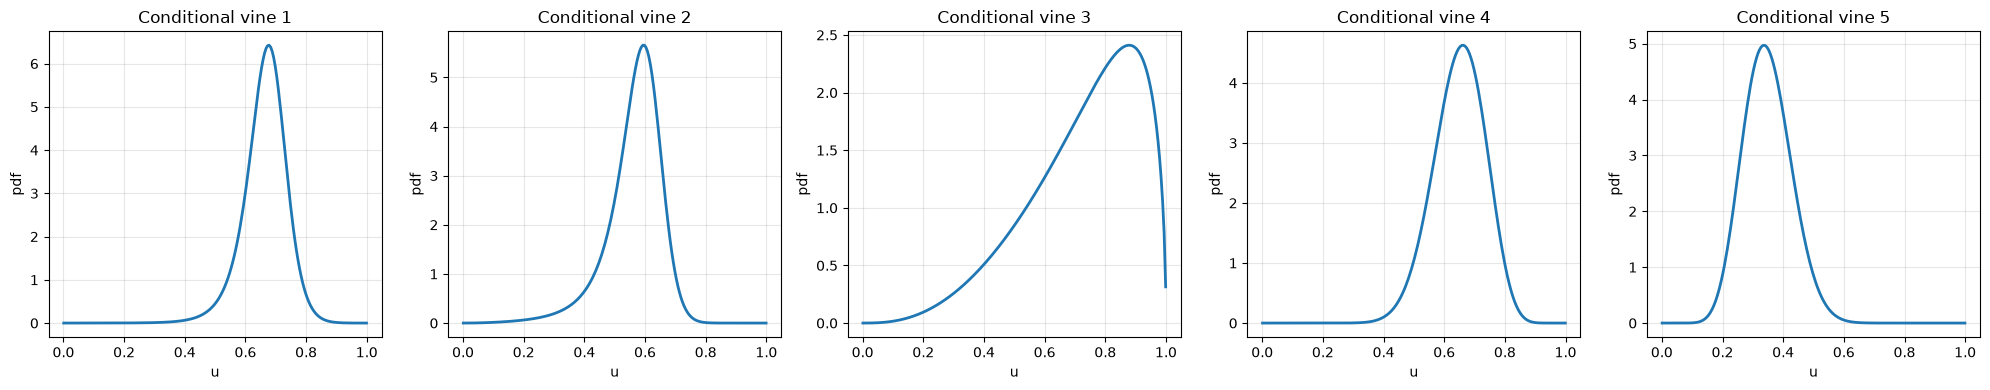

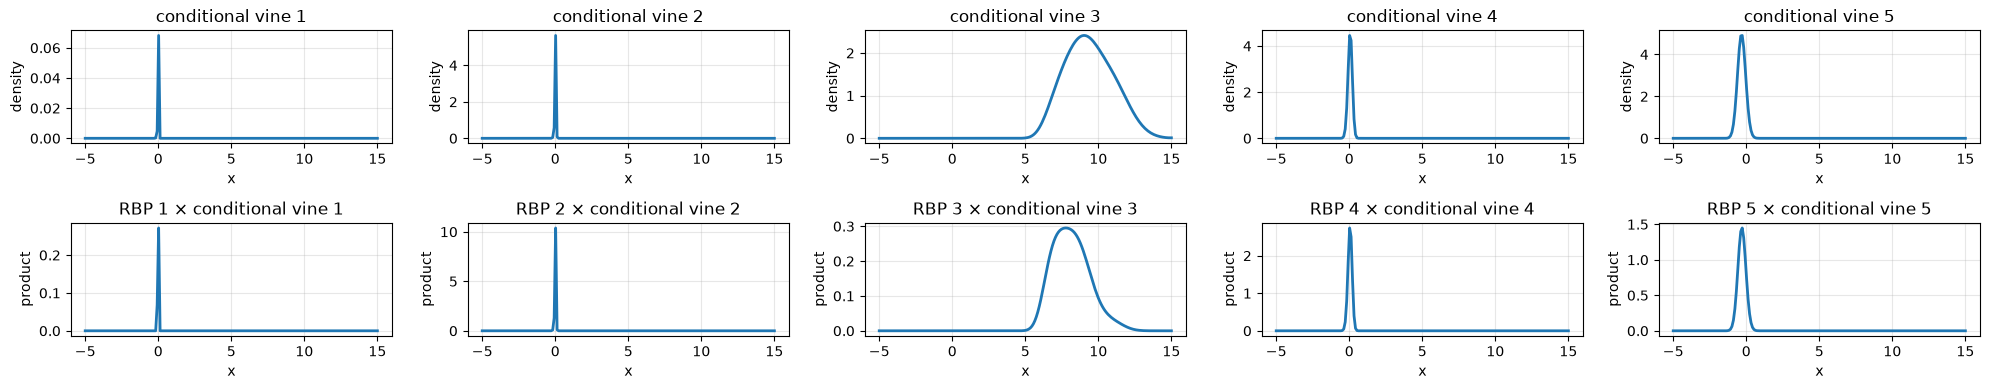

In [ ]:
#print(tv.pdf_predictive(np.array([observations[-2]]),0))
# fig, ax = tv.check_rbp_times_conditional_vine()

# plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/conditionals")
# start = np.repeat([observations[0]], repeats=2, axis = 0)
# start_act = np.repeat([actions[0]], repeats = 2, axis = 0)
# tv.jump_back(start, start_act)

tv.step_forward(np.array([trans_obs[0]]), trans_acts[0][0])
print(tv.last_state.shape)
print(np.array([trans_obs[0]]))

print("Starting Metropolis Hastings")
# var = .0001
# prop = mh.mvn_def(covariance=var)
# sample = mh.sample_mvn(covariance=var)
predicted_next = np.zeros_like(observations)
predicted_up_err = np.zeros_like(observations)
predicted_down_err = np.zeros_like(observations)
predicted_next[0] = observations[0]

#tv.check_rbp_pdfs_real_line()
tv.check_rbp_pdfs_real_line()
tv.check_rbp_times_conditional_vine()
plt.show()

# plt.plot(trans_data[:,0])
# plt.plot(trans_data[:,1])
# plt.plot(trans_data[:,2])
# plt.plot(trans_data[:,3])
# plt.plot(trans_data[:,4])
# plt.plot(trans_acts)

In [4]:
tv.step_forward(np.array([trans_obs[0]]), trans_acts[0][0])

for i, act in enumerate(trans_acts[0:-1]):
    # target = target_func(tv, act[0], log=True)
    # #chain, ar = mh.metropolis_hastings(target, prop, sample, np.array(observations[i+2]), symmetric_proposal=True, chain_length=800, burn_in=500)
    # chain = mh.adaptive_mh(target, torch.tensor(predicted_next[i], dtype = torch.double), torch.eye(4, dtype=torch.double)*var, nmoves = 700, return_entire_chain=True, adapt_no=100, burn_in=400)

    pred, pred_std, ar, fig = tv.predict_next_state(action = act[0], covariance=0.0005, chain_length=600, burn_in = 300, check_chain=False)

    # fig.savefig(f"C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/chain{i}")
    # plt.show()
    # plt.close()

    predicted_next[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred, axis=0)))
    predicted_up_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred+pred_std, axis=0)))
    predicted_down_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred-pred_std, axis=0)))

    # Calculate prediction, prediction variance
    # predicted_next[i+1] = torch.mean(chain, axis = 0)
    # predicted_std[i+1] = torch.std(chain, axis = 0)

    print(i, act[0], ar)

    # We would draw a sample from the policy here to determine the action.

    # Move the tv_vinecop to the last prediction and the action given that state.
    tv.step_forward(np.array([pred]), trans_acts[i+1][0])


0 0.46207021958095523 0.3639398998330551
1 -0.8852759462252712 0.44073455759599334
2 1.1787999527582553 0.3656093489148581
3 0.517085794871043 0.37061769616026713
4 -1.4150787961105178 0.4323873121869783
5 -0.44268330456223676 0.333889816360601
6 -2.3591520434041446 0.328881469115192
7 0.00021147332233016828 0.32387312186978295
8 0.702040390406237 0.25542570951585974
9 1.6336288376497186 0.2938230383973289
10 0.3399167147935164 0.39232053422370616
11 -0.5442791932447198 0.38564273789649417
12 1.796208717111158 0.41569282136894825
13 0.4476749982346347 0.22036727879799667
14 0.8230302259160175 0.1285475792988314
15 -4.679494852211719 0.44240400667779634
16 -0.5980597954936913 0.3789649415692821
17 -1.6296374695416231 0.35225375626043404
18 0.2673808352510279 0.3088480801335559
19 0.08971062926582722 0.29716193656093487
20 2.2004913809624953 0.2587646076794658
21 -4.0133039515287585 0.2704507512520868
22 -3.490328877425016 0.41569282136894825
23 1.0858345139763577 0.3105175292153589
24 1

In [5]:
fig, ax = plt.subplots(2,4)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(4):
    ax[0, i].plot(x, observations[:,i], label = "Observed")
    ax[0, i].plot(x, predicted_next[:,i], label = "Prediction")
    ax[0, i].fill_between(
        x,
        predicted_up_err[:, i],
        predicted_down_err[:, i],
        color = "orange",
        alpha=0.25,
        label="Prediction uncertainty"
    )
    ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_no_observations_transformed_unstandardised")
plt.close()


In [6]:
print(ar)

0.4273789649415693
